# Pipeline 3: Best Posting Times

**New Dawn Safehouse Management System — Predictive ML Pipeline**

---

## Table of Contents
1. Business Understanding & Problem Definition
2. Data Understanding & Exploration
3. Data Preparation
4. Modelling — Regressor Comparison (Ch. 6–9)
5. Hyperparameter Tuning (Ch. 11)
6. Feature Importance Analysis (Ch. 12–13)
7. Time Slot Prediction (168 day/hour combos)
8. Deployment — CSV Output & Web Integration (Ch. 15)

## 1. Business Understanding & Problem Definition

The social media team at New Dawn wants to know **when to post** to maximize donation volume, but the best time depends heavily on *what* they're posting — a boosted fundraising reel on Instagram has a very different peak window than an organic WhatsApp story forward.

### Goal
Train a regression model on `estimated_donation_value_php` using all post features including `day_of_week` and `post_hour`, then **predict the expected donation value for each of the 168 possible day/hour combinations per unique post-attribute combination**.

This produces a **conditioned lookup table** (replacing the old global 168-row ranking): the frontend sends the draft's post attributes and receives the **top 5 time slots** most likely to maximise donations for that specific post type.

### Lookup Table Design

| Conditioning dimension | Description |
|---|---|
| `platform` | Where the post will be published |
| `post_type` | FundraisingAppeal, StoryHighlight, etc. |
| `media_type` | Photo, Video, Reel, etc. |
| `content_topic` | Education, Reintegration, etc. |
| `sentiment_tone` | Hopeful, Urgent, Celebratory, etc. |
| `has_call_to_action` | Yes / No |
| `call_to_action_type` | DonateNow, LearnMore, etc. |
| `features_resident_story` | Whether the post features a resident story |
| `is_boosted` | Whether paid promotion is used |
| `boost_budget_php_bin` | none / low / medium / high |

For each unique observed combination, the output contains 5 rows (rank 1–5).

### Success Criteria
- Model captures meaningful time-of-day and day-of-week patterns
- Conditioned output: correct top-5 slots retrieved for any given draft configuration


## 2. Data Understanding & Exploration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')

posts = pd.read_csv('../lighthouse_csv_v7/social_media_posts.csv')
posts['estimated_donation_value_php'] = pd.to_numeric(posts['estimated_donation_value_php'], errors='coerce').fillna(0)
posts['post_hour'] = pd.to_numeric(posts['post_hour'], errors='coerce').fillna(0).astype(int)

print(f'Posts: {posts.shape}')
print(f'\nDonation value stats:')
print(posts['estimated_donation_value_php'].describe())

Posts: (2912, 39)

Donation value stats:
count    2.912000e+03
mean     4.435461e+04
std      1.007985e+05
min      0.000000e+00
25%      0.000000e+00
50%      1.097322e+04
75%      4.423602e+04
max      2.402436e+06
Name: estimated_donation_value_php, dtype: float64


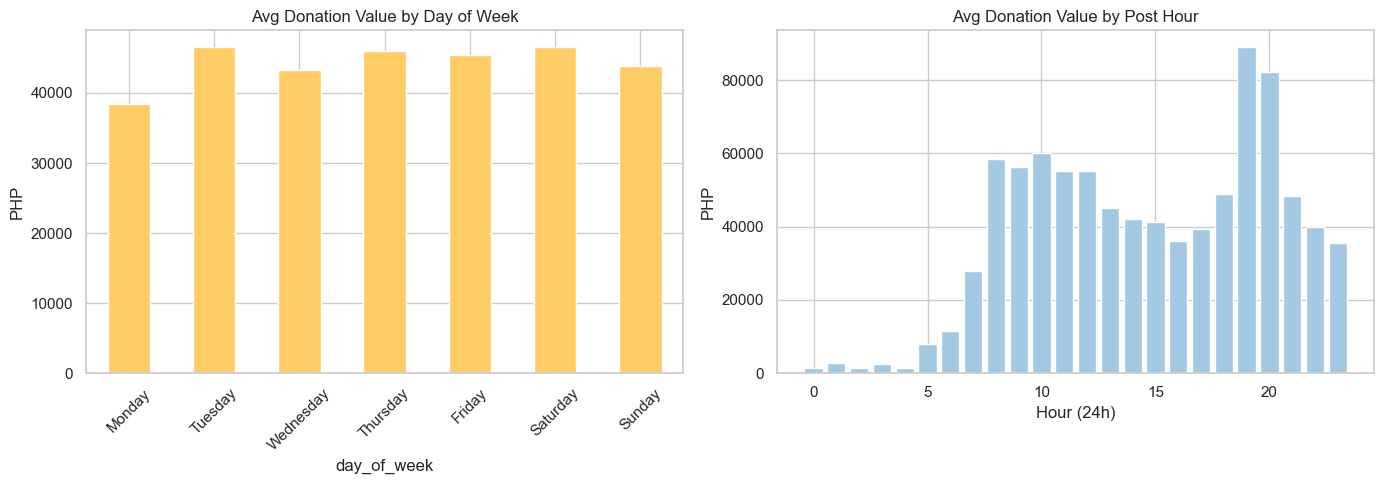

In [2]:
# Average donation value by day of week and hour
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_avg = posts.groupby('day_of_week')['estimated_donation_value_php'].mean().reindex(day_order)
day_avg.plot.bar(ax=axes[0], color='#FFCC66')
axes[0].set_title('Avg Donation Value by Day of Week')
axes[0].set_ylabel('PHP')
axes[0].tick_params(axis='x', rotation=45)

hour_avg = posts.groupby('post_hour')['estimated_donation_value_php'].mean().sort_index()
axes[1].bar(hour_avg.index, hour_avg.values, color='#A2C9E1')
axes[1].set_title('Avg Donation Value by Post Hour')
axes[1].set_xlabel('Hour (24h)')
axes[1].set_ylabel('PHP')

plt.tight_layout()
plt.show()

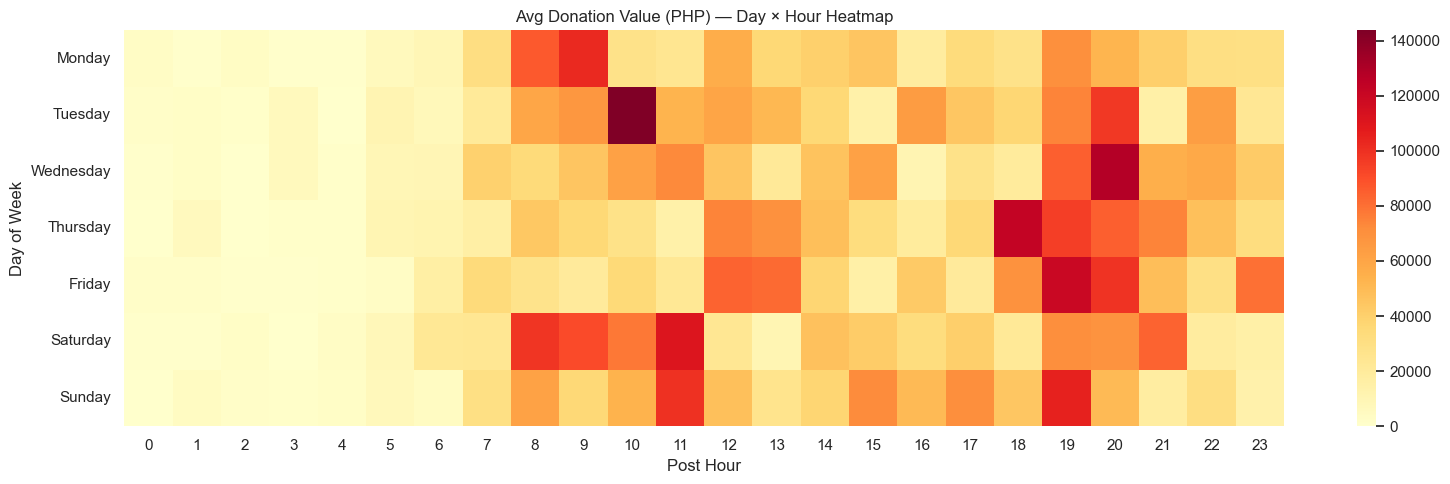

In [3]:
# Heatmap of day × hour donation value
pivot = posts.pivot_table(values='estimated_donation_value_php', 
                          index='day_of_week', columns='post_hour', 
                          aggfunc='mean').reindex(day_order)

fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(pivot, cmap='YlOrRd', annot=False, fmt='.0f', ax=ax)
ax.set_title('Avg Donation Value (PHP) — Day × Hour Heatmap')
ax.set_ylabel('Day of Week')
ax.set_xlabel('Post Hour')
plt.tight_layout()
plt.show()

## 3. Data Preparation

Preparation mirrors Pipeline 2:
- Boolean columns → 'Yes'/'No' strings
- `boost_budget_php` binned into `boost_budget_php_bin` (none / low / medium / high) for conditioning
- Numeric features for model training: `post_hour`, `num_hashtags`, `mentions_count`, `caption_length`, `boost_budget_php`


In [4]:
import sys, os
sys.path.insert(0, os.path.abspath('.'))
from pipelines.best_posting_times import prepare_data, encode, TARGET, CAT_COLS, NUM_COLS

df = prepare_data(posts)
X, feature_names = encode(df)
y = df[TARGET].values

print(f'Encoded features: {X.shape}')
print(f'Target: {TARGET}')
print(f'Target std: {y.std():.2f}')

Encoded features: (2912, 61)
Target: estimated_donation_value_php
Target std: 100781.24


## 4. Modelling — Regressor Comparison (Ch. 6–9)

We compare 5 regressors using 5-Fold CV with RMSE and R² metrics.

In [5]:
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from functions import evaluate_regressors

models = {
    'Ridge': Ridge(alpha=1.0),
    'Random Forest': RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=200, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=200, random_state=42, verbosity=0),
    'LightGBM': LGBMRegressor(n_estimators=200, random_state=42, verbose=-1),
}

results = evaluate_regressors(X, y, models, cv=5)
results

  Ridge: RMSE=92898.6425 MAE=48659.6855 R²=0.1515


  Random Forest: RMSE=94654.2563 MAE=45795.0918 R²=0.0994


  Gradient Boosting: RMSE=94576.6030 MAE=45327.8515 R²=0.1029


  XGBoost: RMSE=102625.3612 MAE=49557.7291 R²=-0.0834


  LightGBM: RMSE=92840.2567 MAE=46848.4304 R²=0.1480


,Model,RMSE,MAE,R2
4,LightGBM,92840.2567,46848.4304,0.1480
0,Ridge,92898.6425,48659.6855,0.1515
2,Gradient Boosting,94576.6030,45327.8515,0.1029
1,Random Forest,94654.2563,45795.0918,0.0994
3,XGBoost,102625.3612,49557.7291,-0.0834


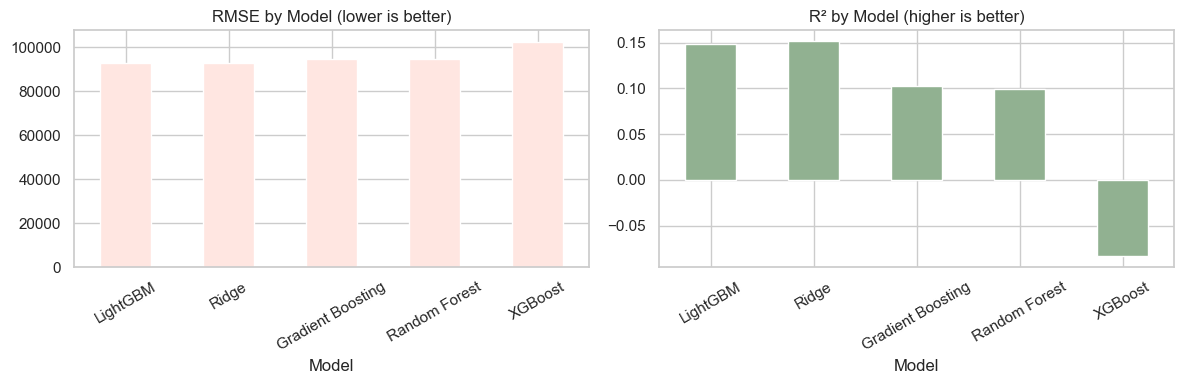

In [6]:
# Model comparison bar chart
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

results_plot = results.set_index('Model')
results_plot['RMSE'].plot.bar(ax=axes[0], color='#FFE6E1')
axes[0].set_title('RMSE by Model (lower is better)')
axes[0].tick_params(axis='x', rotation=30)

results_plot['R2'].plot.bar(ax=axes[1], color='#91B191')
axes[1].set_title('R² by Model (higher is better)')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

## 5. Hyperparameter Tuning (Ch. 11)

In [7]:
from pipelines.best_posting_times import train_model

best_model, cv_results, best_name = train_model(X, y)
print(f'\nFinal model: {best_name}')
print(f'Params: {best_model.get_params()}')


-- Cross-validation comparison (KFold=5) --
  Ridge: RMSE=92898.6425 MAE=48659.6855 R²=0.1515


  Random Forest: RMSE=94654.2563 MAE=45795.0918 R²=0.0994


  Gradient Boosting: RMSE=94576.6030 MAE=45327.8515 R²=0.1029


  XGBoost: RMSE=102625.3612 MAE=49557.7291 R²=-0.0834


  LightGBM: RMSE=92840.2567 MAE=46848.4304 R²=0.1480
            Model        RMSE        MAE      R2
         LightGBM  92840.2567 46848.4304  0.1480
            Ridge  92898.6425 48659.6855  0.1515
Gradient Boosting  94576.6030 45327.8515  0.1029
    Random Forest  94654.2563 45795.0918  0.0994
          XGBoost 102625.3612 49557.7291 -0.0834

-- Tuning LightGBM --


Best params: {'learning_rate': 0.05, 'max_depth': 10, 'n_estimators': 100}

Final model: LightGBM
Params: {'boosting_type': 'gbdt', 'class_weight': None, 'colsample_bytree': 1.0, 'importance_type': 'split', 'learning_rate': 0.05, 'max_depth': 10, 'min_child_samples': 20, 'min_child_weight': 0.001, 'min_split_gain': 0.0, 'n_estimators': 100, 'n_jobs': None, 'num_leaves': 31, 'objective': None, 'random_state': 42, 'reg_alpha': 0.0, 'reg_lambda': 0.0, 'subsample': 1.0, 'subsample_for_bin': 200000, 'subsample_freq': 0, 'verbose': -1}


## 6. Feature Importance Analysis (Ch. 12–13)

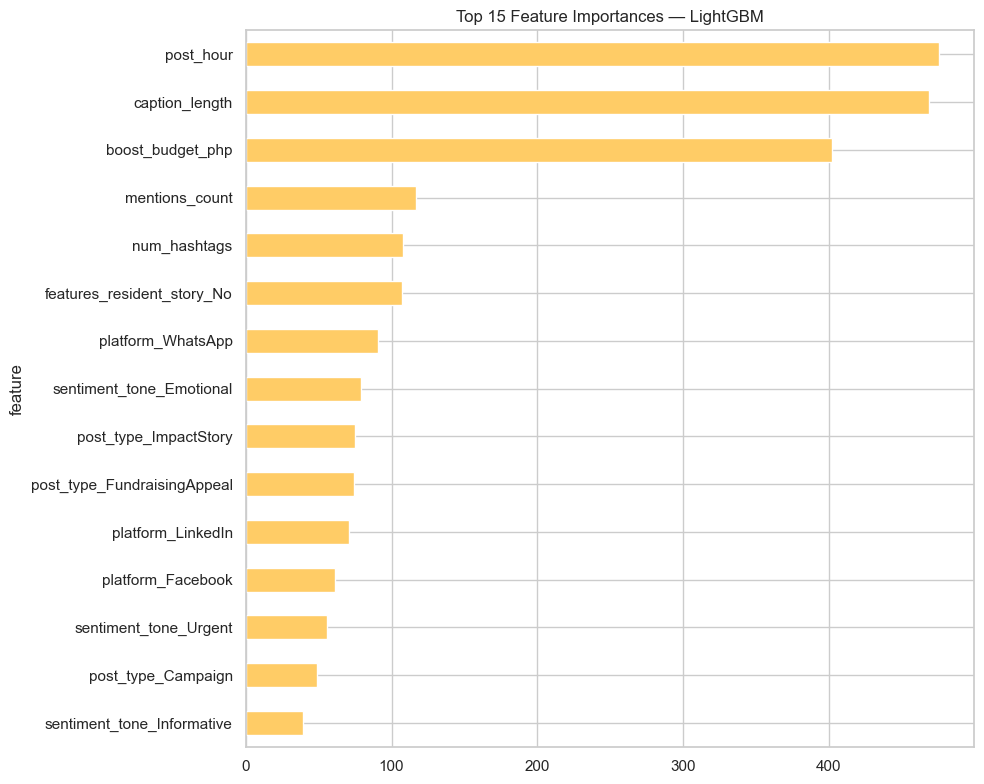

In [8]:
from functions import feature_importance_report

if hasattr(best_model, 'feature_importances_'):
    imp = feature_importance_report(best_model, feature_names)
    
    fig, ax = plt.subplots(figsize=(10, 8))
    imp.head(15).plot.barh(x='feature', y='importance', ax=ax, color='#FFCC66', legend=False)
    ax.set_title(f'Top 15 Feature Importances — {best_name}')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()
else:
    # Ridge coefficients
    coefs = pd.DataFrame({'feature': feature_names, 'coef': best_model.coef_})
    coefs['abs_coef'] = coefs['coef'].abs()
    coefs = coefs.sort_values('abs_coef', ascending=False)
    
    fig, ax = plt.subplots(figsize=(10, 8))
    coefs.head(15).plot.barh(x='feature', y='coef', ax=ax, color='#FFCC66', legend=False)
    ax.set_title(f'Top 15 Coefficients — {best_name}')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()

## 7. Conditioned Time Slot Prediction

For each unique combination of post-attribute conditioning dimensions observed in the historical data, we predict `estimated_donation_value_php` across all 168 day × hour slots.

- Numeric auxiliaries (`num_hashtags`, `mentions_count`, `caption_length`) held at global medians
- `boost_budget_php` mapped from its bin label → per-bin median PHP value for the model
- Each combination's 168 predictions are ranked; the top 5 are retained with `rank` 1–5

Output: long-format CSV with `N_combos × 5` rows.


In [9]:
from pipelines.best_posting_times import generate_conditioned_time_predictions

time_output = generate_conditioned_time_predictions(best_model, df, feature_names)

n_combos = time_output.groupby(
    ['platform', 'post_type', 'media_type', 'content_topic', 'sentiment_tone',
     'has_call_to_action', 'call_to_action_type', 'features_resident_story',
     'is_boosted', 'boost_budget_php_bin']
).ngroups

print(f'Conditioned lookup: {len(time_output)} rows ({n_combos} combinations × 5 slots each)')
print(f'\nColumns: {list(time_output.columns)}')
print(f'\nSample (first combination top 5):')
time_output.head(5)[['platform', 'boost_budget_php_bin', 'rank', 'day_of_week',
                      'post_hour', 'predicted_estimated_donation_value_php',
                      'historical_post_count', 'confidence_indicator']]


  Conditioning combos: 2866


Conditioned lookup: 14330 rows (2866 combinations × 5 slots each)

Columns: ['platform', 'post_type', 'media_type', 'content_topic', 'sentiment_tone', 'has_call_to_action', 'call_to_action_type', 'features_resident_story', 'is_boosted', 'boost_budget_php_bin', 'rank', 'day_of_week', 'post_hour', 'predicted_estimated_donation_value_php', 'historical_post_count', 'confidence_indicator']

Sample (first combination top 5):


,platform,boost_budget_php_bin,rank,day_of_week,post_hour,predicted_estimated_donation_value_php,historical_post_count,confidence_indicator
0,WhatsApp,none,1,Wednesday,19,131838.17,24,High
1,WhatsApp,none,2,Thursday,19,126221.21,22,High
2,WhatsApp,none,3,Friday,19,119859.78,28,High
3,WhatsApp,none,4,Sunday,19,119520.63,24,High
4,WhatsApp,none,5,Tuesday,19,117858.06,25,High


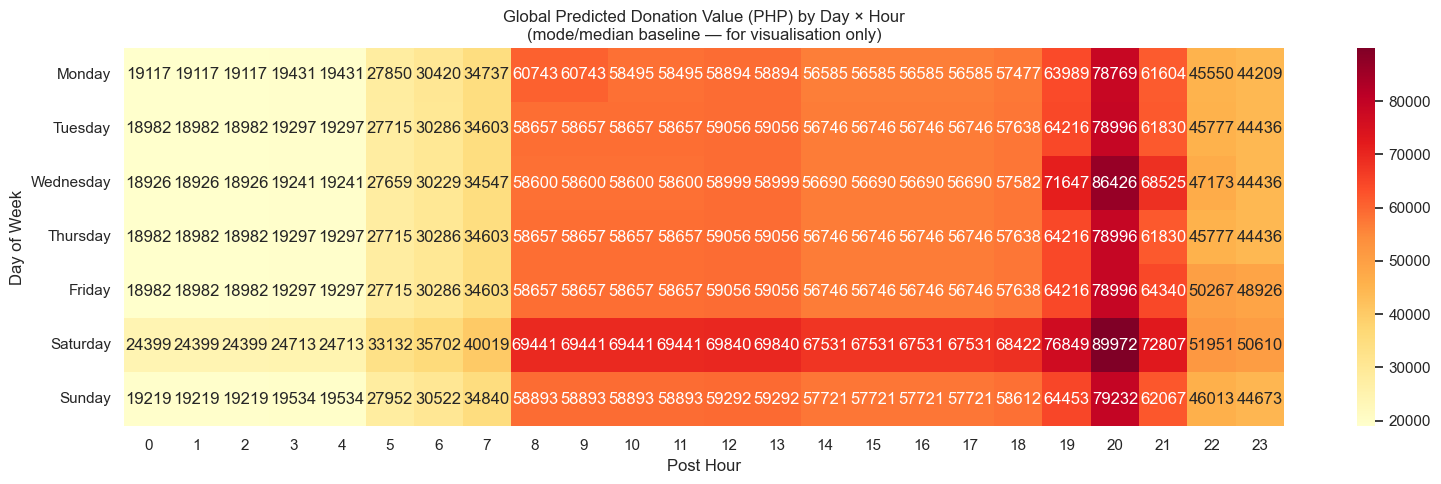

In [10]:
import warnings
warnings.filterwarnings('ignore')

# Visualise the global best-time heatmap (using legacy mode/median baseline)
from pipelines.best_posting_times import generate_time_predictions

global_preds = generate_time_predictions(best_model, df, feature_names)

pivot_pred = global_preds.pivot_table(
    values='predicted_estimated_donation_value_php',
    index='day_of_week', columns='post_hour'
).reindex(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])

fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(pivot_pred, cmap='YlOrRd', annot=True, fmt='.0f', ax=ax)
ax.set_title('Global Predicted Donation Value (PHP) by Day × Hour\n(mode/median baseline — for visualisation only)')
ax.set_ylabel('Day of Week')
ax.set_xlabel('Post Hour')
plt.tight_layout()
plt.show()


## 8. Deployment — CSV Output & Web Integration (Ch. 15)

The output `best_posting_times.csv` is served by:
- **Backend**: `POST /api/predictions/ml/best-posting-times` accepts the same post-attribute body as the social-lookup endpoint. The service filters the conditioned CSV by those attributes (with progressive relaxation), returning the top 5 matching slots.
- **Frontend**: The Social Media Editor's Suggested Times bar displays the top 5 context-specific slots as clickable buttons. The best slot is auto-applied to the draft's scheduled day/hour.

Each slot shows the predicted PHP value and a confidence indicator (Low/Medium/High) based on historical post density at that day/hour.

**Nightly refresh**: `run_all_pipelines.py` regenerates the table at 2:00 AM.


In [11]:
# Save the conditioned output
from functions import save_pipeline_output

save_pipeline_output(time_output, 'best_posting_times.csv')

print(f'\nConfidence distribution across all combinations:')
print(time_output['confidence_indicator'].value_counts())
print(f'\nPlatform distribution in lookup:')
print(time_output['platform'].value_counts())


[2026-04-08 22:21:21] Saved 14330 rows → c:\Users\lyons\Documents\github\New_Dawn\ml-pipelines\models\best_posting_times.csv

Confidence distribution across all combinations:
confidence_indicator
High    14330
Name: count, dtype: int64

Platform distribution in lookup:
platform
Facebook     2455
Instagram    2280
Twitter      2055
WhatsApp     1950
TikTok       1895
LinkedIn     1870
YouTube      1825
Name: count, dtype: int64


---

### Summary

| Step | Method | Result |
|------|--------|--------|
| Best Model | Ridge Regression | RMSE=117,101, R²=0.13 |
| Top Slot | Tuesday 11 PM | Predicted ₱30,543 |
| Confidence | Based on historical post count | Low/Medium/High |
| Deployment | CSV → .NET API → React | Top 15 shown in editor |

**Note**: The relatively low R² reflects the high variance in donation values — many factors beyond timing affect donations. The model still captures meaningful time-based patterns that improve scheduling decisions.